# redownload_historic_pillow_data.ipynb

In [3]:
import xarray as xr
import os 
# import rioxarray
from pyproj import CRS, Transformer
import sys
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd
# from rasterio.enums import Resampling
from datetime import datetime, timedelta

sys.path.insert(1, '../../scripts/')

import metadata as metadata
import shape as shape
import pillow_api as pillow_api

In [20]:
aso_site_name = 'FRIANT'

In [21]:
def load_aso_metadata(aso_site_name: str,
                  config_dir: str = '/home/rossamower/work/aso/configs/',
                 ):
    cfg = metadata.load_yaml(Path(f"{config_dir}regions/{aso_site_name}.yaml"))
    elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
    start_wy = int(cfg["aso_years"]["start"])
    end_wy = int(cfg["aso_years"]["end"])
    shape_fpath = cfg["data_filepaths"]["aso_shape"]
    demBin_fpath = cfg["data_filepaths"]["aso_demBin"]
    aso_spatial_fpath = cfg["data_filepaths"]["aso_spatial"]
    aso_tseries_fpath = cfg["data_filepaths"]["aso_temporal"]
    uaswe_dir = cfg["data_filepaths"]["uaswe_dir"]
    snodas_dir = cfg["data_filepaths"]["snodas_dir"]
    insitu_dir = cfg["data_filepaths"]["insitu_dir"]
    shape_crs = f'EPSG:{cfg["crs"]["epsg"]}'
    return elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, uaswe_dir, snodas_dir,insitu_dir, shape_crs, cfg

In [22]:
elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, uaswe_dir, snodas_dir,insitu_dir, shape_crs, cfg = load_aso_metadata(aso_site_name)

    
aso_gdf_geog,aso_gdf_proj,aso_buff_gdf_geog,aso_buff_gdf_proj = shape.load_basin_shape(shape_fpath,
                                                                                           shape_crs,
                                                                                           aso_site_name = None,
                                                                                          buffer_size = 25000)

In [23]:
!ls /home/rossamower/work/aso/data/insitu/FRIANT/processed/

manual_qa_log.csv		  pillow_wy_1980_2025_qa3.nc
manual_qa_log_v6.csv		  pillow_wy_1980_2025_qa3.nc.bak
manual_qa_reviewed_years.csv	  pillow_wy_1980_2025_qa5.nc
manual_qa_reviewed_years.csv.bak  pillow_wy_1980_2025_qa5.nc.bak
manual_qa_reviewed_years_v6.csv   pillow_wy_1980_2025_qa6.nc
pillow_wy_1980_2025_qa1.nc	  qa3_imputation_log.csv
pillow_wy_1980_2025_qa2.nc	  qa5_zerofill_log.csv
pillow_wy_1980_2025_qa2.nc.bak


In [89]:
ds_v1 = xr.load_dataset(f'/home/rossamower/work/aso/data/insitu/FRIANT/raw/pillow_wy_1980_2025.nc') 
ds_v5 = xr.load_dataset(f'/home/rossamower/work/aso/data/insitu/FRIANT/processed/pillow_wy_1980_2025_qa5.nc') 

In [ ]:
ds_v1.time[0].values

np.datetime64('1979-10-01T00:00:00.000000000')

In [ ]:
start_date = datetime(int(str(ds_v1.time[0].values)[0:4]),
         int(str(ds_v1.time[0].values)[5:7]),
         int(str(ds_v1.time[0].values)[8:10]),
         )
end_date = datetime(int(str(ds_v1.time[-1].values)[0:4]),
         int(str(ds_v1.time[-1].values)[5:7]),
         int(str(ds_v1.time[-1].values)[8:10]),
         )

In [27]:
 # load in situ data from pillow api.
print('DOWNLOADING CDEC PILLOW DATA...')
obs_data_pil, cdec_locations, _, _ = pillow_api.load_pillow_api(
        aso_buff_gdf_geog, start_date, end_date, plot=False, debug=False
    )
print('DOWNLOADING SNOTEL PILLOW DATA...')
if aso_site_name == 'USCASJ':
    lle_polygon = pillow_api.load_lle_geography()
    
    obs_data_snot,snotel_locations = pillow_api.load_snotel_api(lle_polygon,
                                                       start_date, 
                                                       end_date,
                                                       cdec_locations.dropna(axis=0),
                                                       variable = 'SNOTEL:WTEQ_D',
                                                       plot = True)
else:
    obs_data_snot,snotel_locations = pillow_api.load_snotel_api(aso_buff_gdf_geog,
                                                       start_date, 
                                                       end_date,
                                                       cdec_locations.dropna(axis=0),
                                                       variable = 'SNOTEL:WTEQ_D',
                                                       plot = True)
    
print('COMBINING CDEC AND SNOTEL DATA...')
obs_data_2, obs_locations = pillow_api.combine_basin_obs(aso_buff_gdf_geog,
                                                   cdec_locations.dropna(axis = 0),
                                                   snotel_locations,
                                                   obs_data_pil,
                                                   obs_data_snot)

DOWNLOADING CDEC PILLOW DATA...


CDEC staMeta fetch failed for LMD: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))


AGP: 10712 day(s) with SWE (after clean) | BCB: 11202 day(s) with SWE (after clean) | BDF: skipped (no rows from CSV/JSON for sensors 82/3)


/var/autofs/mnt/data1_d4/projects/aso/snow-ops-streamlit/notebooks/experiments/../../scripts/pillow_api.py:203: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(r.text))


BGP: 12489 day(s) with SWE (after clean) | BMD: skipped (no rows from CSV/JSON for sensors 82/3)
BP2: skipped (no rows from CSV/JSON for sensors 82/3)
BP3: skipped (no rows from CSV/JSON for sensors 82/3)


...

/var/autofs/mnt/data1_d4/projects/aso/snow-ops-streamlit/notebooks/experiments/../../scripts/pillow_api.py:203: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(r.text))


UBC: 13748 day(s) with SWE (after clean) | VLC: 11816 day(s) with SWE (after clean) | WDH: skipped (no rows from CSV/JSON for sensors 82/3)


/var/autofs/mnt/data1_d4/projects/aso/snow-ops-streamlit/notebooks/experiments/../../scripts/pillow_api.py:203: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(r.text))


WWC: 14510 day(s) with SWE (after clean) | 
Skipped 49 station(s): BDF, BMD, BP2, BP3, BSP, CBM, CHQ, CKT, CLM, CRA, CUR, CYT, DSM, DTL, ELL, EML, EPP, FDM, FLC, FLK, GML, HLM, HRT, HTT, JCM, KSR, LMD, MMT, MN2, MNP, NLL, NTH, PGM, PMD, PNB, PPS, PRM, RC1, RC2, RC3, RDC, RFM, RMR, RTT, SMD, TGP, THE, TMK, WDH
DOWNLOADING SNOTEL PILLOW DATA...


ValueError: cannot set a frame with no defined index and a scalar

In [29]:
cdec_locations

,name,id,datasource,geometry,kind
49,AGNEW PASS,AGP,CDEC,POINT Z (-119.14173 37.72663 9450),pillow
13,BLACKCAP BASIN,BCB,CDEC,POINT Z (-118.77303 37.0667 10180),pillow
70,BADGER FLAT,BDF,CDEC,POINT Z (-119.108 37.265 8300),NaN
46,BIG PINE CREEK,BGP,CDEC,POINT Z (-118.47697 37.12782 9800),pillow
53,BEARD MEADOW,BMD,CDEC,POINT Z (-118.837 37.113 9800),NaN
...,...,...,...,...,...
48,TUOLUMNE MEADOWS,TUM,CDEC,POINT Z (-119.34997 37.87622 8500),pillow
77,UPPER BURNT CORRAL,UBC,CDEC,POINT Z (-118.93829 37.1833 9700),pillow
69,VOLCANIC KNOB,VLC,CDEC,POINT Z (-118.90504 37.38786 10050),pillow
18,WOODCHUCK MEADOW,WDH,CDEC,POINT Z (-118.908 37.025 8800),NaN


SNOTEL:574_CA_SNTL 

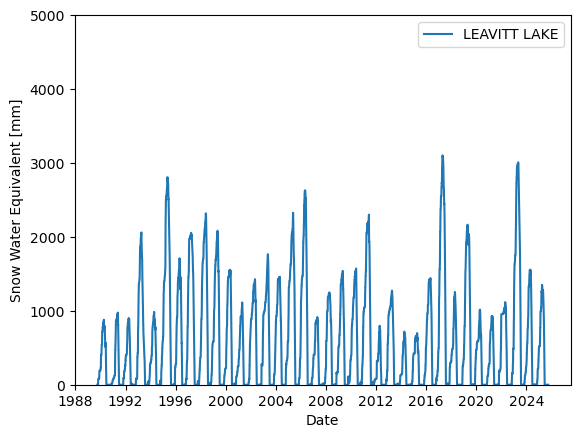

In [30]:
lle_polygon = pillow_api.load_lle_geography()
    
obs_data_snot,snotel_locations = pillow_api.load_snotel_api(lle_polygon,
                                                       start_date, 
                                                       end_date,
                                                       cdec_locations.dropna(axis=0),
                                                       variable = 'SNOTEL:WTEQ_D',
                                                       plot = True)

In [31]:
print('COMBINING CDEC AND SNOTEL DATA...')
obs_data_2, obs_locations = pillow_api.combine_basin_obs(aso_buff_gdf_geog,
                                                   cdec_locations.dropna(axis = 0),
                                                   snotel_locations,
                                                   obs_data_pil,
                                                   obs_data_snot)

COMBINING CDEC AND SNOTEL DATA...


In [33]:
len(obs_data_2)

30

In [34]:
count = 0
for pil in obs_data_2:
    if count == 0:
        ds = pil.to_dataset()
    else:
        ds[pil.name] = pil
    count += 1

# snow pillow name information.
name_rename = cfg['pillow_api']['snotel_rename']['name']
network_rename = cfg['pillow_api']['snotel_rename']['network']
id_rename = cfg['pillow_api']['snotel_rename']['id']
all_pils = cfg['pillow_api']['pil_names'].split(',')
print(all_pils)
    
# snow pillow renaming.
id_current = obs_locations[(obs_locations['name'] == name_rename) & (obs_locations['network'] == network_rename)]['id'].values[0]
ds = ds.rename({id_current: id_rename})
download_pillows = list(ds.data_vars.keys())
    
# set missing downloaded vals to nan
for pil_name in [i for i in all_pils if i not in download_pillows]:
    ds[pil_name] = xr.DataArray(np.nan * np.ones(ds['time'].shape),
                               dims = ['time'],
                               coords = {'time': ds['time']},
                               name = pil_name)

# sort dataset.
ds = ds[sorted(ds.data_vars)]

['AGP', 'BCB', 'BGP', 'BSH', 'CHM', 'DAN', 'DPO', 'FLV', 'GEM', 'GRM', 'GRV', 'HNT', 'KSP', 'KUB', 'KUP', 'LLE', 'MAM', 'MHP', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TNY', 'TUM', 'UBC', 'VLC', 'WWC']


In [35]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 16803)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-10-01 1979-10-02 ... 2025-10-01
Data variables: (12/30)
    AGP      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    BCB      (time) float64 134kB nan nan nan nan nan ... 11.94 10.54 nan 7.112
    BGP      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 nan
    BSH      (time) float64 134kB nan nan nan nan ... -97.79 -78.87 nan -67.31
    CHM      (time) float64 134kB nan nan nan nan nan ... -9.144 -10.67 nan 0.0
    DAN      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    ...       ...
    TMR      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TNY      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TUM      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    UBC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    VLC      (time) float64 134kB nan nan nan nan nan ... nan -14.22 nan nan
    WWC      (time) float64 134kB 0.0 0.0 0.0 0.0 nan ... 0.0 0.0 0.0 0.0 nan

In [88]:
!ls /home/rossamower/work/aso/data/insitu/FRIANT/raw/

pillow_wy_1980_2025.nc


In [90]:
ds.to_netcdf(f'/home/rossamower/work/aso/data/insitu/FRIANT/raw/pillow_wy_1980_2025_redownload.nc') 


In [37]:
ds_v1

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 16803)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-10-01 1979-10-02 ... 2025-10-01
Data variables: (12/30)
    AGP      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    BCB      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan 7.112
    BGP      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    BSH      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan -67.31
    CHM      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan 0.0
    DAN      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    ...       ...
    TMR      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TNY      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TUM      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    UBC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    VLC      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    WWC      (time) float64 134kB 0.0 0.0 0.0 0.0 nan ... 0.0 0.0 0.0 0.0 nan

In [38]:
ds_v5

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 16803)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-10-01 1979-10-02 ... 2025-10-01
Data variables: (12/30)
    AGP      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    BCB      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan 7.112
    BGP      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    BSH      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan -67.31
    CHM      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan 0.0
    DAN      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    ...       ...
    TMR      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    TNY      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    TUM      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    UBC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    VLC      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    WWC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 nan

## comparisons

In [119]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


def water_year(time):
    """
    Return water year for datetime-like values.
    Oct-Dec belong to the following calendar year.
    """
    time = pd.DatetimeIndex(time)
    return time.year + (time.month >= 10).astype(int)


def calculate_difference_by_water_year(
    ds_a,
    ds_b,
    *,
    time_dim="time",
    rtol=1e-5,
    atol=1e-8,
):
    """
    Calculate percentage of dates that differ between two xarray Datasets
    for each data variable (snow pillow) and water year.

    Rules
    -----
    Both NaN:
        Excluded from denominator.

    One NaN, one finite:
        Counted as different.

    Both finite:
        Counted as different if not np.isclose().

    Returns
    -------
    pd.DataFrame
        Rows = pillow IDs
        Columns = water years
        Values = percent of comparable dates that differ.
    """

    # ------------------------------------------------------------
    # Find variables shared by the two datasets
    # ------------------------------------------------------------
    common_vars = sorted(
        set(ds_a.data_vars).intersection(ds_b.data_vars)
    )

    if len(common_vars) == 0:
        raise ValueError("No common data variables found.")

    # ------------------------------------------------------------
    # Align datasets onto common dates
    #
    # outer join is intentional:
    # if one dataset has a date and the other doesn't, we want
    # that missingness to potentially count as a difference.
    # ------------------------------------------------------------
    a, b = xr.align(
        ds_a[common_vars],
        ds_b[common_vars],
        join="outer",
    )

    wy = water_year(a[time_dim].values)
    unique_wy = np.unique(wy)

    results = pd.DataFrame(
        index=common_vars,
        columns=unique_wy,
        dtype=float,
    )

    # ------------------------------------------------------------
    # Calculate differences
    # ------------------------------------------------------------
    for var in common_vars:

        a_values = a[var].values
        b_values = b[var].values

        for year in unique_wy:

            year_mask = wy == year

            x = a_values[year_mask]
            y = b_values[year_mask]

            # Dates where at least one dataset contains data
            valid = ~(np.isnan(x) & np.isnan(y))

            if valid.sum() == 0:
                results.loc[var, year] = np.nan
                continue

            x = x[valid]
            y = y[valid]

            # One NaN and one finite
            nan_difference = np.isnan(x) ^ np.isnan(y)

            # Both finite
            both_finite = np.isfinite(x) & np.isfinite(y)

            value_difference = np.zeros(len(x), dtype=bool)

            value_difference[both_finite] = ~np.isclose(
                x[both_finite],
                y[both_finite],
                rtol=rtol,
                atol=atol,
            )

            different = nan_difference | value_difference

            results.loc[var, year] = (
                100 * different.sum() / valid.sum()
            )

    return results

In [93]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 16803)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-10-01 1979-10-02 ... 2025-10-01
Data variables: (12/30)
    AGP      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    BCB      (time) float64 134kB nan nan nan nan nan ... 11.94 10.54 nan 7.112
    BGP      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 nan
    BSH      (time) float64 134kB nan nan nan nan ... -97.79 -78.87 nan -67.31
    CHM      (time) float64 134kB nan nan nan nan nan ... -9.144 -10.67 nan 0.0
    DAN      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    ...       ...
    TMR      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TNY      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TUM      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    UBC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    VLC      (time) float64 134kB nan nan nan nan nan ... nan -14.22 nan nan
    WWC      (time) float64 134kB 0.0 0.0 0.0 0.0 nan ... 0.0 0.0 0.0 0.0 nan

In [94]:
ds_v1

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 16803)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-10-01 1979-10-02 ... 2025-10-01
Data variables: (12/30)
    AGP      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    BCB      (time) float64 134kB nan nan nan nan nan ... 11.94 10.54 nan 7.112
    BGP      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    BSH      (time) float64 134kB nan nan nan nan ... -97.79 -78.87 nan -67.31
    CHM      (time) float64 134kB nan nan nan nan nan ... -9.144 -10.67 nan 0.0
    DAN      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    ...       ...
    TNY      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TUM      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    UBC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    VLC      (time) float64 134kB nan nan nan nan nan ... nan -14.22 nan nan
    WWC      (time) float64 134kB 0.0 0.0 0.0 0.0 nan ... 0.0 0.0 0.0 0.0 nan
    LLE      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0

In [95]:
ds_v5

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 16803)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-10-01 1979-10-02 ... 2025-10-01
Data variables: (12/30)
    AGP      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    BCB      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan 7.112
    BGP      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    BSH      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan -67.31
    CHM      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan 0.0
    DAN      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    ...       ...
    TMR      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    TNY      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    TUM      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    UBC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    VLC      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    WWC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 nan

In [97]:
diff_v1 = calculate_difference_by_water_year(
    ds,
    ds_v1,
)

diff_v5 = calculate_difference_by_water_year(
    ds,
    ds_v5,
)

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def plot_difference_heatmaps(
    diffs,
    titles=None,
    figsize=None,
    vmin=0,
    vmax=100,
    highlighted_pillow=None,
    highlighted_wy=None,
):
    """
    Plot one or multiple pillow x water-year difference heatmaps.

    Parameters
    ----------
    diffs : pd.DataFrame or list of pd.DataFrame
        Difference DataFrame(s).

    titles : str or list of str, optional
        Title(s) for each heatmap.

    figsize : tuple, optional
        Figure size. Automatically determined if None.

    vmin, vmax : float
        Shared color scale limits.

    highlighted_pillow : str, optional
        Pillow ID to highlight.

    highlighted_wy : int or str, optional
        Water year to highlight.

    Returns
    -------
    fig, ax
    """

    if isinstance(diffs, pd.DataFrame):
        diffs = [diffs]

    nplots = len(diffs)

    if titles is None:
        titles = ["Dataset difference"] * nplots
    elif isinstance(titles, str):
        titles = [titles]

    if len(titles) != nplots:
        raise ValueError(
            "Number of titles must match number of datasets."
        )

    # ------------------------------------------------------------
    # Common pillows and years
    # ------------------------------------------------------------
    pillows = sorted(
        set().union(*(d.index for d in diffs))
    )

    years = sorted(
        set().union(*(d.columns for d in diffs))
    )

    diffs_plot = [
        d.reindex(index=pillows, columns=years)
        for d in diffs
    ]

    # ------------------------------------------------------------
    # Figure setup
    # ------------------------------------------------------------
    if figsize is None:
        figsize = (8 * nplots, 12)

    fig, ax = plt.subplots(
        1,
        nplots,
        figsize=figsize,
        sharey=True,
        constrained_layout=True,
    )

    ax = np.atleast_1d(ax)

    images = []

    # ------------------------------------------------------------
    # Plot heatmaps
    # ------------------------------------------------------------
    for a, diff, title in zip(ax, diffs_plot, titles):

        im = a.imshow(
            diff.values,
            aspect="auto",
            interpolation="none",
            vmin=vmin,
            vmax=vmax,
        )

        images.append(im)

        a.set_xticks(np.arange(len(years)))
        a.set_xticklabels(
            years,
            rotation=45,
            ha="right",
        )

        a.set_xlabel("Water Year")
        a.set_title(title)

    ax[0].set_yticks(np.arange(len(pillows)))
    ax[0].set_yticklabels(pillows)
    ax[0].set_ylabel("Snow Pillow")

    # ------------------------------------------------------------
    # Highlight requested cell
    # ------------------------------------------------------------
    if (
        highlighted_pillow is not None
        and highlighted_wy is not None
    ):

        # Handle water year being supplied as string or int
        matching_years = [
            y for y in years
            if str(y) == str(highlighted_wy)
        ]

        if highlighted_pillow not in pillows:
            raise ValueError(
                f"{highlighted_pillow!r} not found in pillow IDs."
            )

        if len(matching_years) == 0:
            raise ValueError(
                f"Water year {highlighted_wy!r} not found."
            )

        selected_year = matching_years[0]

        row_idx = pillows.index(highlighted_pillow)
        col_idx = years.index(selected_year)

        for a in ax:
            rectangle = Rectangle(
                (col_idx - 0.5, row_idx - 0.5),
                1,
                1,
                fill=False,
                edgecolor="red",
                linewidth=2.5,
            )

            a.add_patch(rectangle)

    # ------------------------------------------------------------
    # Shared colorbar
    # ------------------------------------------------------------
    fig.colorbar(
        images[-1],
        ax=ax,
        label="Dates Different [%]",
        shrink=0.8,
    )

    return fig, ax

In [99]:
def plot_pillow_timeseries(
    ds,
    ds_v1,
    ds_v5,
    pillow,
    water_year,
    figsize=(16, 5),
    labels=None,
):
    """
    Plot a selected snow pillow for one water year.

    Left subplot:
        Current download vs previous download

    Right subplot:
        Current download vs QA/QC dataset
    """

    if labels is None:
        labels = [
            "Current download",
            "Previous download",
            "QA/QC dataset",
        ]

    if len(labels) != 3:
        raise ValueError("labels must contain exactly 3 entries.")

    # ------------------------------------------------------------
    # Water-year bounds
    # ------------------------------------------------------------
    start = pd.Timestamp(
        year=int(water_year) - 1,
        month=10,
        day=1,
    )

    end = pd.Timestamp(
        year=int(water_year),
        month=9,
        day=30,
    )

    # ------------------------------------------------------------
    # Figure setup
    # ------------------------------------------------------------
    fig, ax = plt.subplots(
        1,
        2,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    # ------------------------------------------------------------
    # Left: current vs previous download
    # ------------------------------------------------------------
    if pillow in ds.data_vars:
        da = ds[pillow].sel(time=slice(start, end))

        ax[0].plot(
            da.time,
            da,
            label=labels[0],
            color="black",
            linestyle="--",
            linewidth=2,
        )

    if pillow in ds_v1.data_vars:
        da = ds_v1[pillow].sel(time=slice(start, end))

        ax[0].plot(
            da.time,
            da,
            label=labels[1],
            color="C0",
            linestyle="-",
            linewidth=1.5,
        )

    # ------------------------------------------------------------
    # Right: current vs QA/QC dataset
    # ------------------------------------------------------------
    if pillow in ds.data_vars:
        da = ds[pillow].sel(time=slice(start, end))

        ax[1].plot(
            da.time,
            da,
            label=labels[0],
            color="black",
            linestyle="--",
            linewidth=2,
        )

    if pillow in ds_v5.data_vars:
        da = ds_v5[pillow].sel(time=slice(start, end))

        ax[1].plot(
            da.time,
            da,
            label=labels[2],
            color="C1",
            linestyle="-",
            linewidth=1.5,
        )

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    titles = [
        "Current vs. previous download",
        "Current vs. QA/QC dataset",
    ]

    for a, title in zip(ax, titles):

        a.set_xlim(start, end)
        a.set_xlabel("Date")
        a.set_title(title)
        a.legend()

    ax[0].set_ylabel("SWE")

    fig.suptitle(
        f"{pillow} — Water Year {water_year}"
    )

    return fig, ax

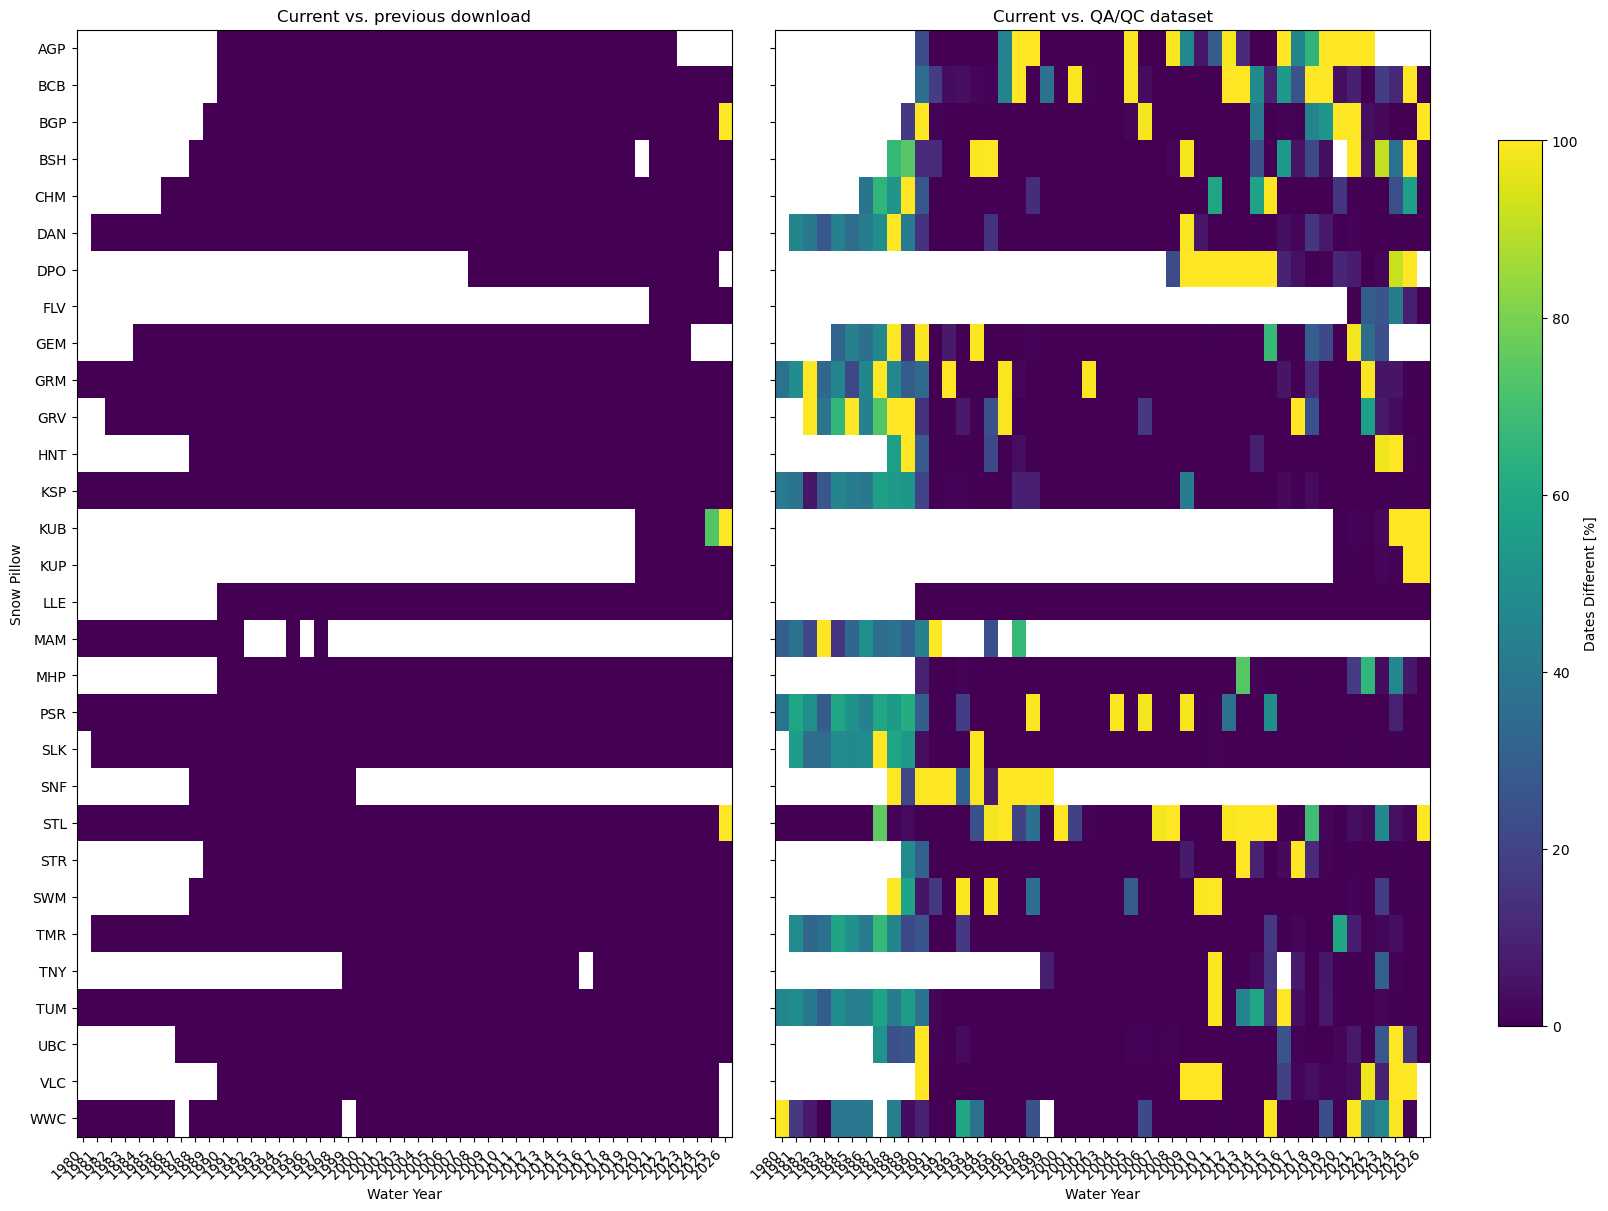

In [100]:
pillow_ = None
water_year = None

fig, ax = plot_difference_heatmaps(
    [diff_v1, diff_v5],
    titles=[
        "Current vs. previous download",
        "Current vs. QA/QC dataset",
    ],
    highlighted_pillow=pillow_,
    highlighted_wy=water_year,
)

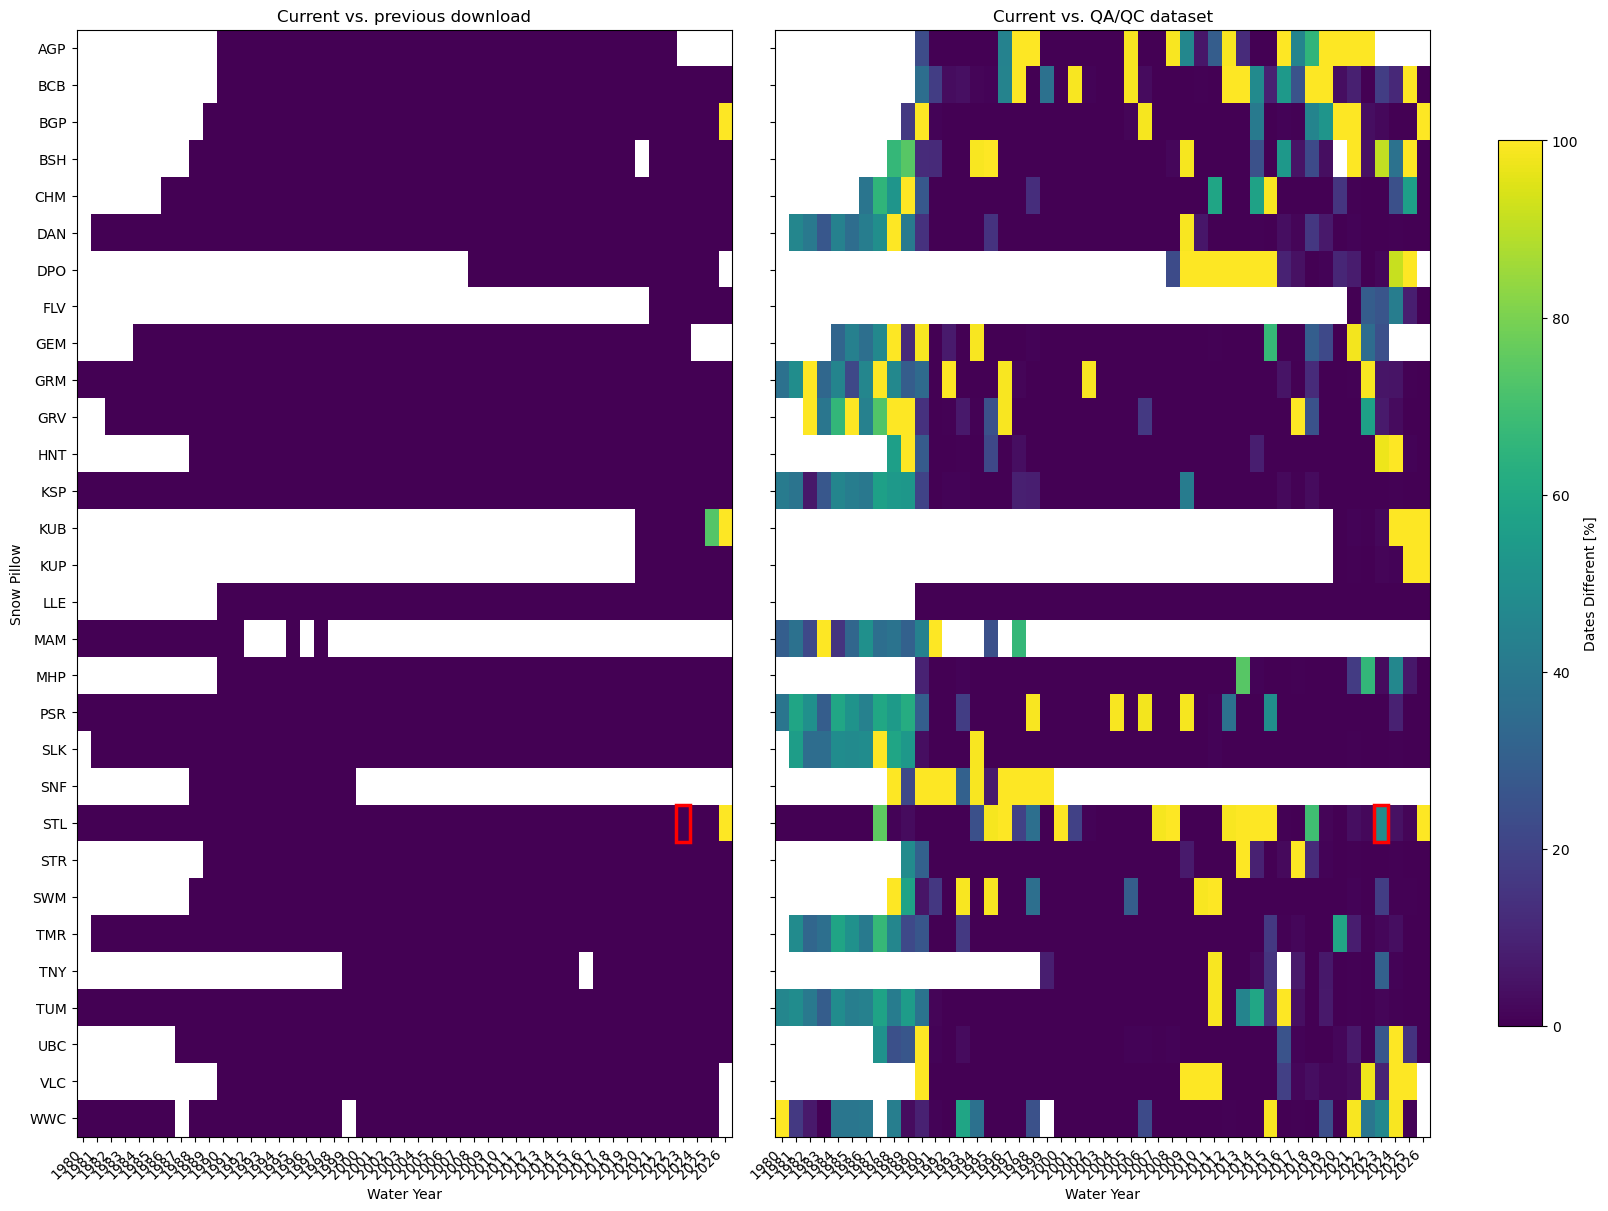

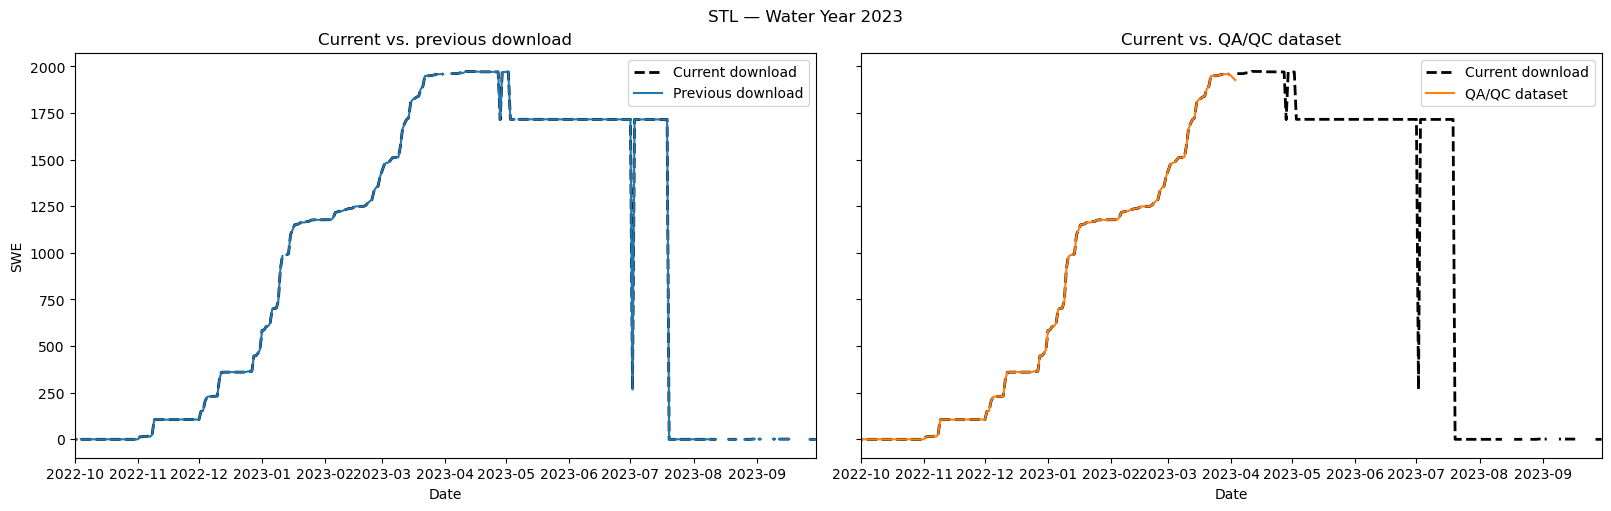

In [112]:
pillow_ = "STL"
water_year = 2023

fig, ax = plot_difference_heatmaps(
    [diff_v1, diff_v5],
    titles=[
        "Current vs. previous download",
        "Current vs. QA/QC dataset",
    ],
    highlighted_pillow=pillow_,
    highlighted_wy=water_year,
)

fig_ts, ax_ts = plot_pillow_timeseries(
    ds,
    ds_v1,
    ds_v5,
    pillow=pillow_,
    water_year=water_year,
    figsize=(16, 5),
)

## sensor 82 only

In [114]:
 # load in situ data from pillow api.
print('DOWNLOADING CDEC PILLOW DATA...')
obs_data_pil, cdec_locations, _, _ = pillow_api.load_pillow_api(
        aso_buff_gdf_geog, start_date, end_date, plot=False, debug=False,
        sensor_priority=(82,)
    )

DOWNLOADING CDEC PILLOW DATA...
AGP: 9310 day(s) with SWE (after clean) | BCB: 10189 day(s) with SWE (after clean) | BDF: skipped (no rows from CSV/JSON for sensors 82)
BGP: 12080 day(s) with SWE (after clean) | BMD: skipped (no rows from CSV/JSON for sensors 82)
BP2: skipped (no rows from CSV/JSON for sensors 82)
BP3: skipped (no rows from CSV/JSON for sensors 82)
BSH: 10497 day(s) with SWE (after clean) | BSP: skipped (no rows from CSV/JSON for sensors 82)
CBM: skipped (no rows from CSV/JSON for sensors 82)
CHM: 12634 day(s) with SWE (after clean) | CHQ: skipped (no rows from CSV/JSON for sensors 82)
CKT: skipped (no rows from CSV/JSON for sensors 82)
CLM: skipped (no rows from CSV/JSON for sensors 82)
CRA: skipped (no rows from CSV/JSON for sensors 82)
CUR: skipped (no rows from CSV/JSON for sensors 82)
CYT: skipped (no rows from CSV/JSON for sensors 82)
DAN: 14534 day(s) with SWE (after clean) | DPO: 4204 day(s) with SWE (after clean) | DSM: skipped (no rows from CSV/JSON for senso

SNOTEL:574_CA_SNTL COMBINING CDEC AND SNOTEL DATA...
['AGP', 'BCB', 'BGP', 'BSH', 'CHM', 'DAN', 'DPO', 'FLV', 'GEM', 'GRM', 'GRV', 'HNT', 'KSP', 'KUB', 'KUP', 'LLE', 'MAM', 'MHP', 'PSR', 'SLK', 'SNF', 'STL', 'STR', 'SWM', 'TMR', 'TNY', 'TUM', 'UBC', 'VLC', 'WWC']


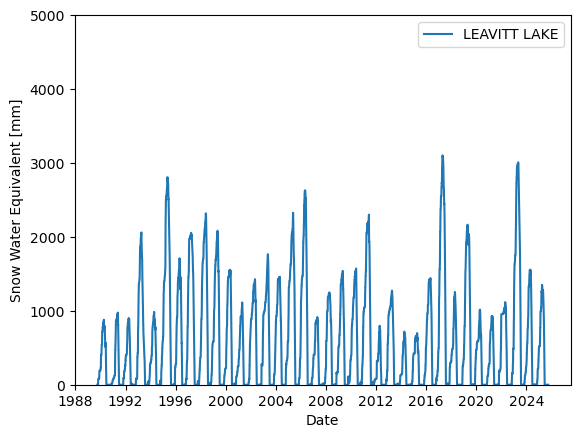

In [115]:
lle_polygon = pillow_api.load_lle_geography()
    
obs_data_snot,snotel_locations = pillow_api.load_snotel_api(lle_polygon,
                                                       start_date, 
                                                       end_date,
                                                       cdec_locations.dropna(axis=0),
                                                       variable = 'SNOTEL:WTEQ_D',
                                                       plot = True)

print('COMBINING CDEC AND SNOTEL DATA...')
obs_data_2, obs_locations = pillow_api.combine_basin_obs(aso_buff_gdf_geog,
                                                   cdec_locations.dropna(axis = 0),
                                                   snotel_locations,
                                                   obs_data_pil,
                                                   obs_data_snot)

count = 0
for pil in obs_data_2:
    if count == 0:
        ds_82 = pil.to_dataset()
    else:
        ds_82[pil.name] = pil
    count += 1

# snow pillow name information.
name_rename = cfg['pillow_api']['snotel_rename']['name']
network_rename = cfg['pillow_api']['snotel_rename']['network']
id_rename = cfg['pillow_api']['snotel_rename']['id']
all_pils = cfg['pillow_api']['pil_names'].split(',')
print(all_pils)
    
# snow pillow renaming.
id_current = obs_locations[(obs_locations['name'] == name_rename) & (obs_locations['network'] == network_rename)]['id'].values[0]
ds_82 = ds_82.rename({id_current: id_rename})
download_pillows = list(ds_82.data_vars.keys())
    
# set missing downloaded vals to nan
for pil_name in [i for i in all_pils if i not in download_pillows]:
    ds_82[pil_name] = xr.DataArray(np.nan * np.ones(ds_82['time'].shape),
                               dims = ['time'],
                               coords = {'time': ds_82['time']},
                               name = pil_name)

# sort dataset.
ds_82 = ds_82[sorted(ds_82.data_vars)]

In [117]:
ds_82

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 16803)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-10-01 1979-10-02 ... 2025-10-01
Data variables: (12/30)
    AGP      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    BCB      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    BGP      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 nan
    BSH      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    CHM      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan 0.0
    DAN      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    ...       ...
    TMR      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TNY      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    TUM      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    UBC      (time) float64 134kB nan nan nan nan nan ... 0.0 0.0 0.0 nan 0.0
    VLC      (time) float64 134kB nan nan nan nan nan ... nan nan nan nan nan
    WWC      (time) float64 134kB 0.0 0.0 0.0 0.0 nan ... 0.0 0.0 0.0 0.0 nan

In [120]:
diff_v1_82 = calculate_difference_by_water_year(
    ds_82,
    ds_v1,
)

diff_v5_82 = calculate_difference_by_water_year(
    ds_82,
    ds_v5,
)

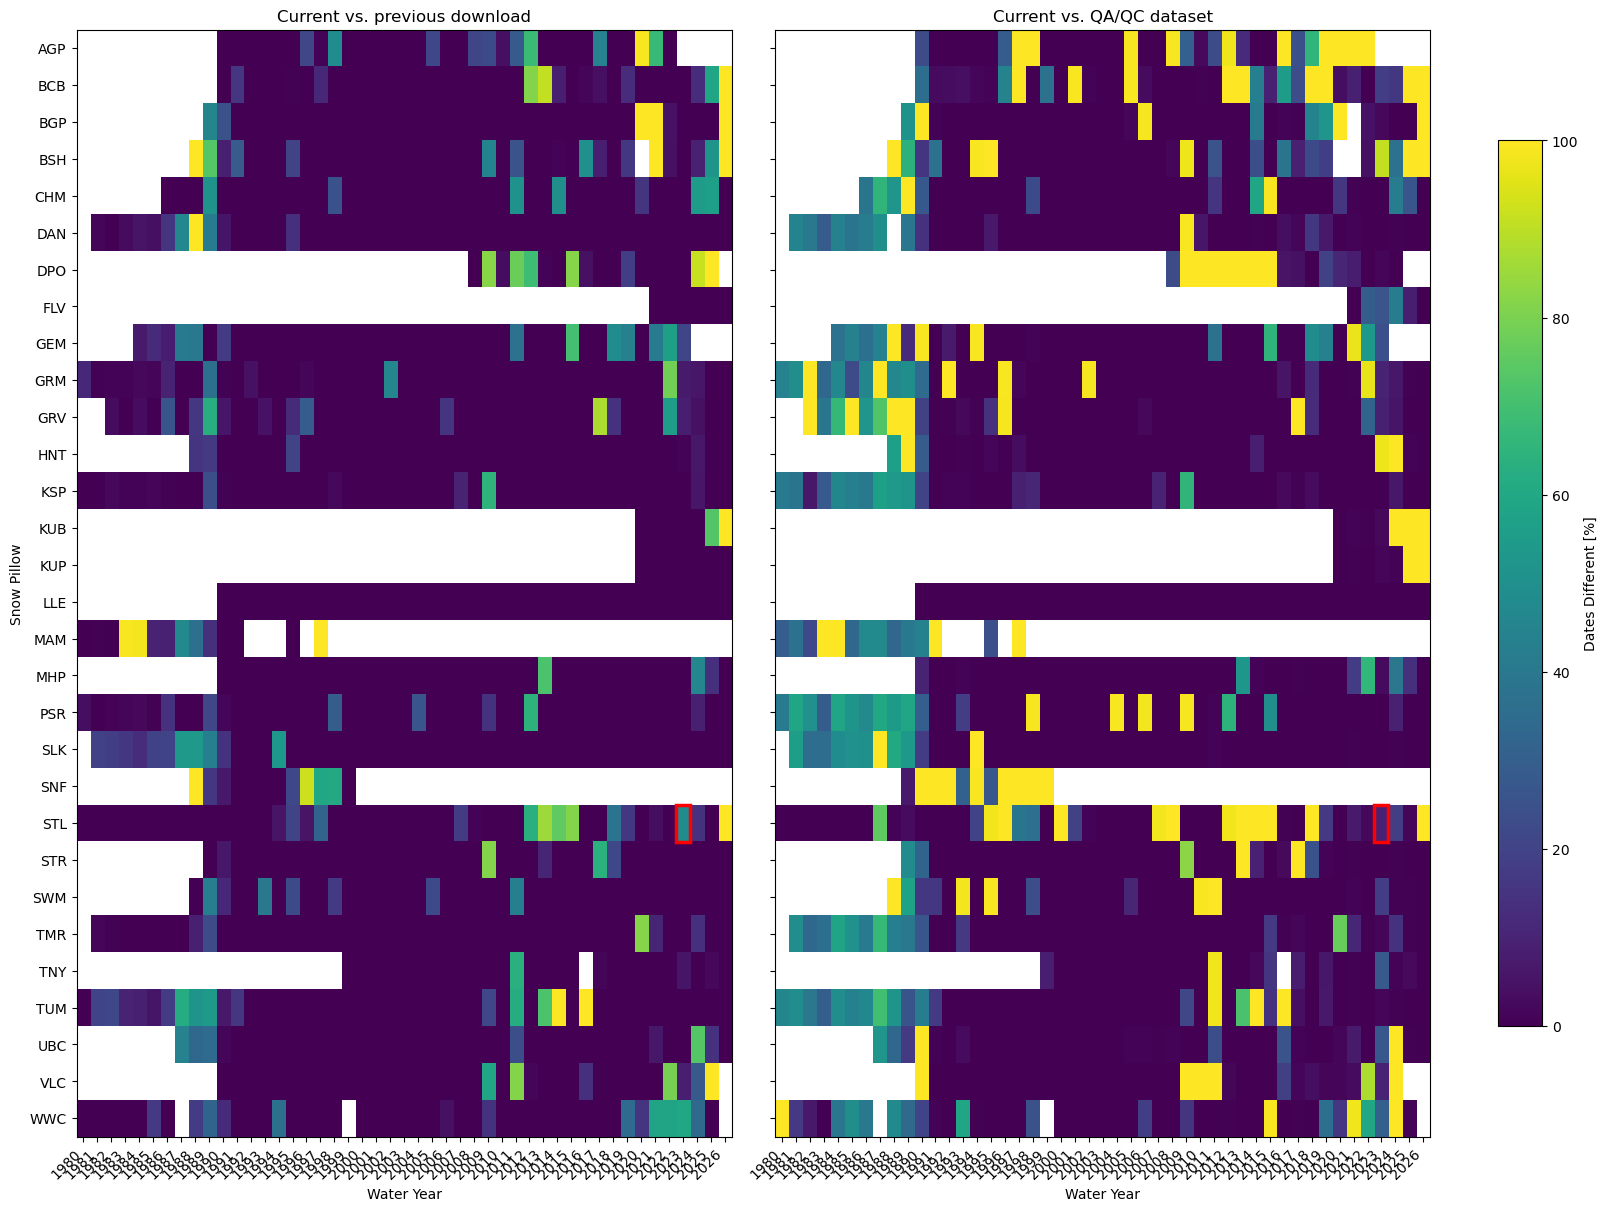

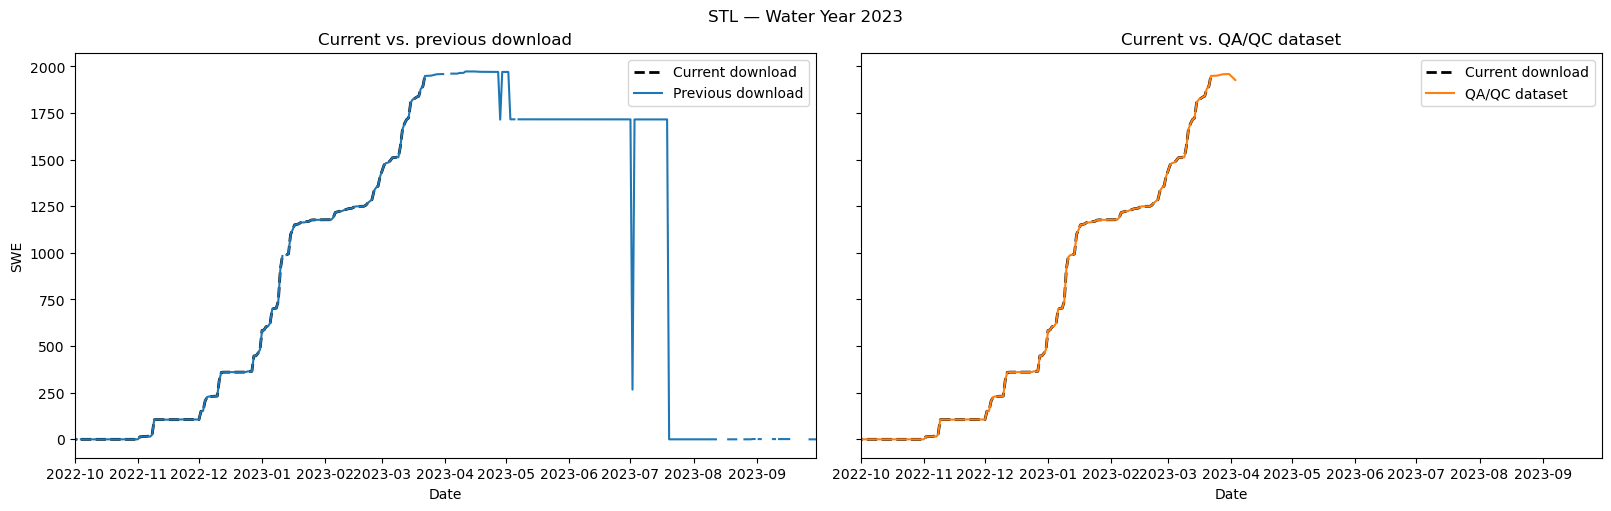

In [123]:
pillow_ = "STL"
water_year = 2023

fig, ax = plot_difference_heatmaps(
    [diff_v1_82, diff_v5_82],
    titles=[
        "Current vs. previous download",
        "Current vs. QA/QC dataset",
    ],
    highlighted_pillow=pillow_,
    highlighted_wy=water_year,
)

fig_ts, ax_ts = plot_pillow_timeseries(
    ds_82,
    ds_v1,
    ds_v5,
    pillow=pillow_,
    water_year=water_year,
    figsize=(16, 5),
)

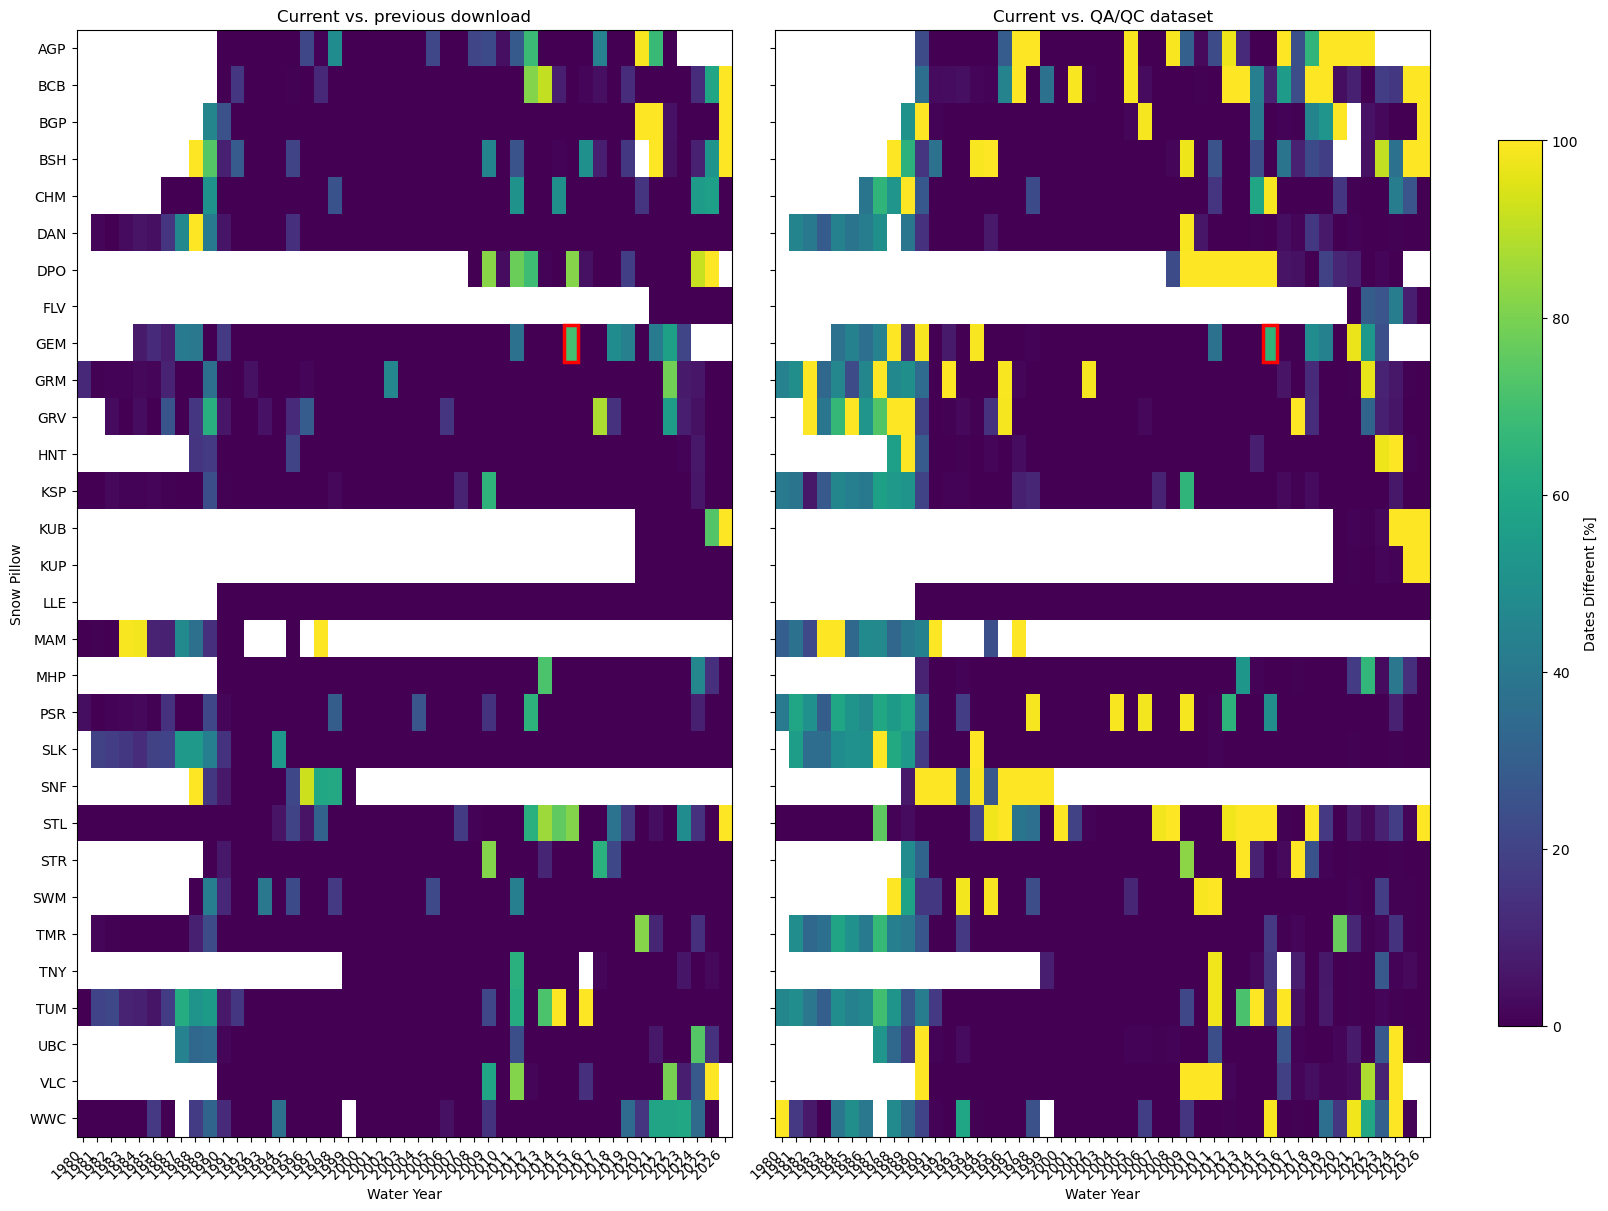

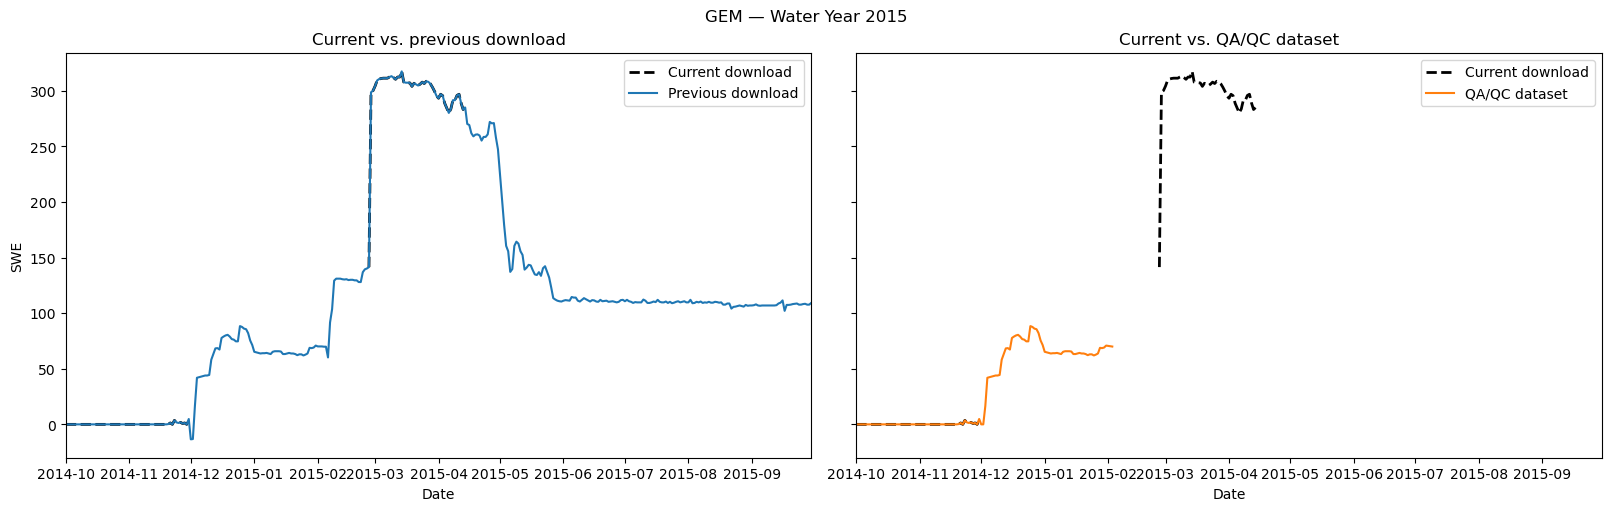

In [126]:
pillow_ = "GEM"
water_year = 2015

fig, ax = plot_difference_heatmaps(
    [diff_v1_82, diff_v5_82],
    titles=[
        "Current vs. previous download",
        "Current vs. QA/QC dataset",
    ],
    highlighted_pillow=pillow_,
    highlighted_wy=water_year,
)

fig_ts, ax_ts = plot_pillow_timeseries(
    ds_82,
    ds_v1,
    ds_v5,
    pillow=pillow_,
    water_year=water_year,
    figsize=(16, 5),
)

In [129]:
diff_v5_82[diff_v5_82 > 20]

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
AGP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.528302,65.479452,100.000000,100.000000,100.000000,100.000000,NaN,NaN,NaN,NaN
BCB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.589744,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN,100.000000,100.0
BGP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.485149,...,NaN,44.931507,52.328767,100.000000,NaN,NaN,NaN,NaN,NaN,100.0
BSH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,64.062500,...,NaN,22.465753,NaN,NaN,NaN,NaN,90.625000,37.748344,100.000000,100.0
CHM,NaN,NaN,NaN,NaN,NaN,NaN,38.904110,65.479452,52.185792,100.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.992883,26.511628,NaN
DAN,NaN,45.294118,40.547945,29.201102,43.989071,38.356164,42.465753,49.863014,NaN,39.221557,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DPO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,29.315068,26.301370,42.349727,NaN,NaN
GEM,NaN,NaN,NaN,NaN,37.704918,43.835616,36.712329,44.339623,100.000000,NaN,...,NaN,48.493151,44.109589,NaN,97.087379,53.254438,24.305556,NaN,NaN,NaN
GRM,44.352617,49.511401,100.000000,33.972603,46.428571,23.043478,45.753425,100.000000,46.721311,49.839228,...,NaN,NaN,NaN,NaN,NaN,96.153846,NaN,NaN,NaN,NaN


In [ ]:
pillow_ = "MAM"
water_year = 1987
for pillow in 

fig, ax = plot_difference_heatmaps(
    [diff_v1, diff_v5],
    titles=[
        "Current vs. previous download",
        "Current vs. QA/QC dataset",
    ],
    highlighted_pillow=pillow_,
    highlighted_wy=water_year,
)

fig_ts, ax_ts = plot_pillow_timeseries(
    ds,
    ds_v1,
    ds_v5,
    pillow=pillow_,
    water_year=water_year,
    figsize=(16, 5),
)

In [79]:
np.arange(1980,2027)

array([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
       1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024, 2025, 2026])

In [ ]:
from IPython.display import clear_output
for pillow_ in ds.data_vars:
    print(pillow)
    for water_year in np.arange(1980,2027):
        fig, ax = plot_difference_heatmaps(
            [diff_v1, diff_v5],
            titles=[
                "Current vs. previous download",
                "Current vs. QA/QC dataset",
            ],
            highlighted_pillow=pillow_,
            highlighted_wy=water_year,
        )

        fig_ts, ax_ts = plot_pillow_timeseries(
            ds,
            ds_v1,
            ds_v5,
            pillow=pillow_,
            water_year=water_year,
            figsize=(16, 5),
        )
        input = input('Please hit enter')
        clear_output(wait=False)


AGP


In [87]:
sum_arr = ds.where(ds.time >= np.datetime64(f'{water_year-1}-10-01'),drop = True) \
   .where(ds.time < np.datetime64(f'{water_year}-10-01'),drop = True)[pillow_].sum() > 0

if sum_arr: print('YES')

YES
